
Самостоятельно напишите нейронную сеть, которая поможет распознавать болезни по симптомам. Используя подготовленную базу, создайте и обучите нейронную сеть, распознающую десять категорий
заболеваний: аппендицит, гастрит, гепатит, дуоденит, колит, панкреатит, холицестит, эзофагит, энтерит, язва. Добейтесь правильного распознавания 6 и более заболеваний

Сразу обратим внимание датасет небольшой и хороших результатов добится  сложно.

Ссылка на датасет:https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip

In [ ]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Вывод объектов в ячейке colab
from IPython.display import display

%matplotlib inline

In [ ]:
# Скачаем архив с симптомами болезней
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip', None, quiet=True)

'diseases.zip'

In [ ]:
# Распакум архив
!unzip -o diseases.zip

Archive:  diseases.zip
  inflating: dis/Аппендицит.txt  
  inflating: dis/Гастрит.txt  
  inflating: dis/Гепатит.txt  
  inflating: dis/Дуоденит.txt  
  inflating: dis/Колит.txt      
  inflating: dis/Панкреатит.txt  
  inflating: dis/Холицестит.txt  
  inflating: dis/Эзофагит.txt  
  inflating: dis/Энтерит.txt  
  inflating: dis/Язва.txt        


In [ ]:
FILE_DIR  = 'dis/'                     # Папка с текстовыми файлами

In [ ]:
# Подготовим пустые списки

CLASS_LIST = []  # Список классов
text_train = []  # Список для оучающей выборки
text_test = []   # Список для тестовой выборки

# Зададим коэффициент разделения текста на обучающую и текстовую выборки
split_coef = 0.8

# Получим списки файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    m = file_name.split('.') # Разделим имя файла и расширение
    class_name = m[0]        # Из имени файла получим название класса
    ext = m[1]               # Выделим расширение файла

    if ext=='txt':                                         # Если расширение txt то берем файл в работу
        if class_name not in CLASS_LIST:                   # Проверим, есть уже такой класс в списке
            print(f'Добавление класса "{class_name}"')     # Выведем имя нового класса
            CLASS_LIST.append(class_name)                  # Добавим новый класс в списоккласса "{class_name}"')

        cls = CLASS_LIST.index(class_name)                                        # Получим индекс (номер) нового класса
        print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}"')      # Сообщим о появлении нового класса

        with open(f'{FILE_DIR}/{file_name}', 'r') as f: # Откроем файл на чтение
            text = f.read()                                                       # Загрузка содержимого файла в строку
            text = text.replace('\n', ' ').split(' ')                             # Уберем символы перевода строк, получим список слов
            text_len=len(text)                                                    # Найдем количество прочитанных слов
            text_train.append(' '.join(text[:int(text_len*split_coef)]))          # Выделим часть файла в обучающую выборку
            text_test.append(' '.join(text[int(text_len*split_coef):]))           # Выделим часть файла в тестовую выборку



Добавление класса "Холицестит"
Добавление файла "Холицестит.txt" в класс "Холицестит"
Добавление класса "Гепатит"
Добавление файла "Гепатит.txt" в класс "Гепатит"
Добавление класса "Аппендицит"
Добавление файла "Аппендицит.txt" в класс "Аппендицит"
Добавление класса "Дуоденит"
Добавление файла "Дуоденит.txt" в класс "Дуоденит"
Добавление класса "Энтерит"
Добавление файла "Энтерит.txt" в класс "Энтерит"
Добавление класса "Язва"
Добавление файла "Язва.txt" в класс "Язва"
Добавление класса "Эзофагит"
Добавление файла "Эзофагит.txt" в класс "Эзофагит"
Добавление класса "Колит"
Добавление файла "Колит.txt" в класс "Колит"
Добавление класса "Панкреатит"
Добавление файла "Панкреатит.txt" в класс "Панкреатит"
Добавление класса "Гастрит"
Добавление файла "Гастрит.txt" в класс "Гастрит"


In [ ]:
# Найдем получившееся количество классов
CLASS_COUNT = len(CLASS_LIST)

In [ ]:
# Выведем число получившихся классов
print(CLASS_COUNT)

10


In [ ]:
# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with

class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

In [ ]:
#ваше решение
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
WIN_SIZE = 150
WIN_HOP = 75

In [ ]:
# Создаем объект токенизатора
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    # Символы, которые будут удалены из текста
    filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
    lower=True,
    split=' ',
    oov_token='неизвестное_слово'
)
# Строим словарь по обучающим текстам
tokenizer.fit_on_texts(text_train)
# Преобразуем тексты в последовательности чисел
# каждое число — индекс слова в словаре
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)

print("Пример текста:")
print(text_train[0][:200])
print("В последовательности:")
print(seq_train[0][:30])

Пример текста:
тупая, ноющая боль в области правого подреберья постоянного характера или возникающая через 1–3 ч после приема обильной и особенно жирной и жареной пищи. Боль иррадиирует вверх, в область правого плеч
В последовательности:
[141, 95, 4, 2, 14, 211, 257, 737, 77, 5, 457, 142, 96, 212, 258, 12, 50, 143, 3, 63, 97, 3, 259, 22, 4, 738, 739, 2, 123, 211]


In [ ]:
import numpy as np
from tensorflow.keras import utils

# разбиение последовательности на окна
def split_sequence(sequence, win_size, hop):
    return [
        sequence[i:i + win_size]
        for i in range(0, len(sequence) - win_size + 1, hop)
    ]

# формирование обучающих данных
def vectorize_sequence(seq_list, win_size, hop):

    class_count = len(seq_list)

    x = []
    y = []

    for cls in range(class_count):

        vectors = split_sequence(seq_list[cls], win_size, hop)

        x.extend(vectors)
        y.extend([utils.to_categorical(cls, class_count)] * len(vectors))

    return np.array(x), np.array(y)

In [ ]:
# сначала объединяем все данные
seq_all = seq_train
y_all = np.arange(len(seq_train))

# векторизация все данных
x_all, y_all = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all.argmax(axis=1)
)

In [ ]:
model = Sequential([
    Embedding(VOCAB_SIZE, 64, input_length=WIN_SIZE),

    Conv1D(64, 3, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(CLASS_COUNT, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=16,
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 749ms/step - accuracy: 0.1034 - loss: 2.3007 - val_accuracy: 0.1333 - val_loss: 2.2760
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2759 - loss: 2.2330 - val_accuracy: 0.1333 - val_loss: 2.2426
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2414 - loss: 2.2087 - val_accuracy: 0.3333 - val_loss: 2.2084
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4310 - loss: 2.1434 - val_accuracy: 0.3333 - val_loss: 2.1780
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4828 - loss: 2.0725 - val_accuracy: 0.3333 - val_loss: 2.1451
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4483 - loss: 2.0684 - val_accuracy: 0.3333 - val_loss: 2.1135
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4655 - loss: 2.0290 - val_accuracy: 0.3333 - val_loss: 2.0823
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4655 - loss: 1.9573 - val_accuracy: 0.3333 - val_loss: 2.0473

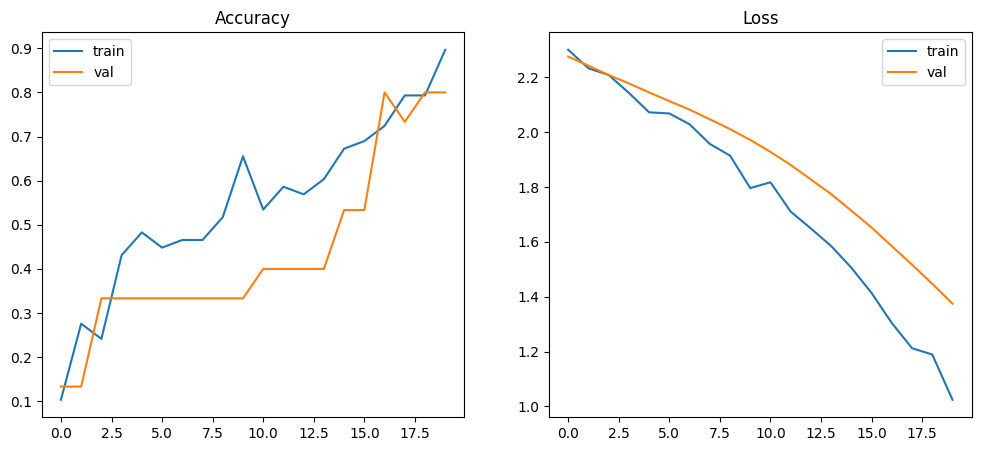

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

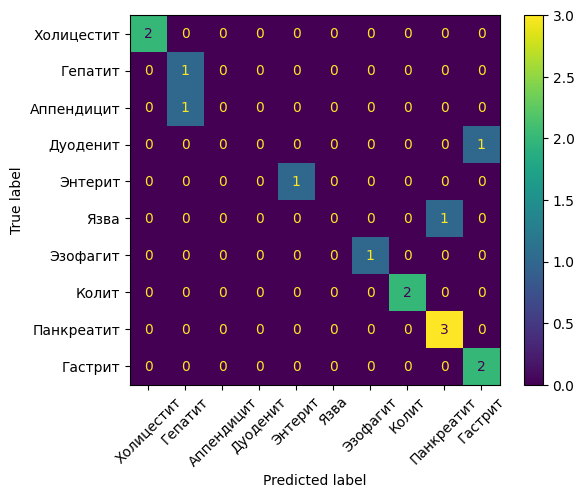

In [ ]:
used_classes = np.unique(np.concatenate([y_true, y_pred_classes]))

class_names = [CLASS_LIST[i] for i in used_classes]

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.show()

In [ ]:
n_pred = len(np.unique(y_pred_classes))
print(f"Предсказанных классов моделью: {n_pred} из {CLASS_COUNT}")

Предсказанных классов моделью: 7 из 10
